# Importacion de la librerias

In [2]:
# !pip install isotree

In [10]:
import pandas as pd
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.utils import shuffle
from sklearn.metrics import precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from joblib import Parallel, delayed
# modern
from isotree import IsolationForest
#

ModuleNotFoundError: No module named 'isotree'

# Cargar los datos

In [4]:
data=('fraud_detection_dataset.csv')

In [5]:
df=pd.read_csv(data)

In [6]:
df.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
0,2023-12-15 02:48:24,3cbf0b8a-c799-4c0e-9782-89272ab8fa2b,998.99,Grantfurt,Mobile,0,56,42524.98,8394.05,655
1,2023-10-30 11:08:37,3675ed98-6863-4bae-b089-6f0db2df006b,241.39,Kimberlychester,Tablet,0,52,69884.04,28434.06,395
2,2023-11-21 05:19:35,4be1043f-20ee-4ac5-a689-b25c6a1de50c,836.42,Gutierrezville,Desktop,0,58,126953.62,39121.78,496
3,2023-11-07 00:03:25,cad0b3c9-099f-479b-8043-6d5ecb4e1467,612.74,Markside,Desktop,0,19,128650.70,39652.48,612
4,2023-04-02 14:12:23,b6ebea7d-ba62-41d7-b042-3978a23fef8b,135.55,Anthonyshire,Tablet,0,59,102020.39,7439.81,302


# Analisis exploratorio (Eda)

- timestamp: The date and time of the transaction / marca de tiempo. 
- user_id: A unique identifier for each user / la id de usuario.
- amount: The transaction amount in currency / cantidad transacciones recurrentes.
- location: The location where the transaction occurred (city)/ la localicacion de transacciones.
- device_type: The type of device used for the transaction (e.g., Desktop, Mobile, Tablet) / tipo de dispositivo.
- age: The age of the user / la edad del usuario.
- income: The income of the user / ingreso del usuario .
- debt: The debt amount associated with the user / deuda del usuario.
- credit_score: The credit score of the user / puntuacion del credito del usuario  .
- is_fraud: Binary indicator (0 or 1) representing whether the transaction is fraudulent (1) or legitimate (0) / ls marca si es fraude o legitima.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   timestamp     object 
 1   user_id       object 
 2   amount        float64
 3   location      object 
 4   device_type   object 
 5   is_fraud      int64  
 6   age           int64  
 7   income        float64
 8   debt          float64
 9   credit_score  int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 152.6+ MB


In [44]:
print('datos vacios', df.isnull().sum().sum())

datos vacios 0


In [45]:
print("conjunto de datos: \n", df.shape)

conjunto de datos: 
 (2000000, 10)


In [9]:
df.describe()

,amount,is_fraud,age,income,debt,credit_score
count,2.000000e+06,2000000.0,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,1.751680e+03,0.5,4.400430e+01,8.502099e+04,2.498404e+04,5.747856e+02
std,1.504160e+03,0.5,1.529754e+01,3.753201e+04,1.444005e+04,1.591240e+02
min,1.000000e+01,0.0,1.800000e+01,2.000009e+04,4.000000e-02,3.000000e+02
25%,5.043400e+02,0.0,3.100000e+01,5.253058e+04,1.246551e+04,4.370000e+02
50%,1.000005e+03,0.5,4.400000e+01,8.503287e+04,2.498093e+04,5.750000e+02
75%,2.996710e+03,1.0,5.700000e+01,1.175375e+05,3.748029e+04,7.130000e+02
max,4.999990e+03,1.0,7.000000e+01,1.500000e+05,4.999998e+04,8.500000e+02


In [46]:
df.groupby('is_fraud').size()

is_fraud
0    1000000
1    1000000
dtype: int64

In [47]:
df.groupby('age').size()

age
18    37696
19    37902
20    37713
21    37944
22    37841
23    37455
24    37728
25    37641
26    37578
27    37649
28    37899
29    37582
30    37914
31    37764
32    37597
33    37446
34    37771
35    37941
36    37597
37    37782
38    37500
39    37851
40    37947
41    37753
42    37628
43    37488
44    37608
45    38022
46    37468
47    38189
48    37590
49    37349
50    37809
51    37936
52    37763
53    37766
54    37630
55    37991
56    37768
57    37733
58    37565
59    37906
60    37764
61    37853
62    38028
63    37647
64    37671
65    37714
66    37754
67    37935
68    37746
69    37613
70    37575
dtype: int64

In [15]:
#

In [48]:
df.groupby('location')['age'].sum()

location
Aaronberg       3170
Aaronborough    3788
Aaronburgh      3990
Aaronbury       3964
Aaronchester    3926
                ... 
Zunigastad       584
Zunigaton        798
Zunigatown       547
Zunigaview       536
Zunigaville      634
Name: age, Length: 104592, dtype: int64

In [8]:
# ciudades_reales

In [28]:
df2=df.copy()

In [29]:
# cate = [['Aaronberg', 'Aaronborough','Aaronburgh','Aaronchester','Zunigastad','Zunigaton','Zunigatown','Zunigaview','Zunigaville']]
#Listar Ciudades
ciudades_reales = df['location'].unique().tolist()
#list
ciudades_reales = [ciudades_reales]
encoder = OrdinalEncoder(categories=ciudades_reales)
df2['location'] = encoder.fit_transform(df[['location']])

# Preparacion de los datos 

In [30]:
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')
df2['timestamp'] = pd.to_datetime(df2['timestamp'], errors='coerce')
# df2['timestamp'] = df2['timestamp'].dt.strftime('%d/%m/%Y')
# df2['timestamp'] = pd.to_datetime(df2['timestamp'], format='%d/%m/%Y')

df2 = df2.sort_values('timestamp')

In [31]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000000 entries, 122783 to 1809779
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   timestamp     datetime64[ns]
 1   user_id       object        
 2   amount        float64       
 3   location      float64       
 4   device_type   object        
 5   is_fraud      int64         
 6   age           int64         
 7   income        float64       
 8   debt          float64       
 9   credit_score  int64         
dtypes: datetime64[ns](1), float64(4), int64(3), object(2)
memory usage: 167.8+ MB


In [14]:
df2.head()

,timestamp,user_id,amount,location,device_type,is_fraud,age,income,debt,credit_score
122783,2023-03-01 14:27:00,b1154e8a-fb91-4662-b35b-510f249b02a6,880.61,14983.0,Desktop,0,67,49737.67,21891.11,319
424592,2023-03-01 14:27:34,c9da94cb-c209-4bef-a8b9-17039ce6bd32,975.28,47450.0,Desktop,0,60,139635.72,23239.11,544
511371,2023-03-01 14:27:56,cd05ec0f-7929-4a0b-81f8-e0b0c6fd05ca,700.97,2924.0,Tablet,0,45,103432.44,5656.16,391
679307,2023-03-01 14:30:13,3ffa2cd6-d2b3-43be-8aa1-75394e5a24d4,196.35,26213.0,Mobile,0,70,140887.09,1433.18,776
700737,2023-03-01 14:30:21,8a6ae893-c740-42cc-9732-e37555bdb5b7,977.56,43276.0,Tablet,0,20,97017.12,5497.52,494


In [32]:
freq_min = '1min'
feature_columns=['amount','age','income','debt','credit_score','is_fraud','location']
# df2_agrupado = df2.groupby('timestamp')[feature_columns].agg(['mean', 'std'])
df2_agrupado = df2.groupby(pd.Grouper(key='timestamp', freq=freq_min))[feature_columns].agg(['mean', 'std'])

df2_agrupado.columns = [
    f'{agg_type.upper()}_{col}' for col, agg_type in df2_agrupado.columns
]

# df2_agrupado.reset_index(inplace=True)

print(df2_agrupado.shape)
df2_agrupado.head()

# Ejemplo: si usas frecuencias de tiempo, intenta algo más granular
# df2['timestamp'] = pd.to_datetime(df2['timestamp'])
# df2_agrupado2 = df2.groupby(pd.Grouper(key='timestamp', freq='1min')).agg(...)

(525949, 14)


,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud,MEAN_location,STD_location
timestamp,,,,,,,,,,,,,,
2023-03-01 14:27:00,852.286667,139.331089,57.333333,11.239810,97601.943333,45231.746230,16928.793333,9785.625821,418.0,114.904308,0.00,0.0,21785.666667,23029.293831
2023-03-01 14:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:30:00,1557.462500,2032.347968,40.500000,22.308444,118672.380000,27867.800779,13227.355000,18239.762965,579.5,174.435279,0.25,0.5,44126.000000,24691.123601
2023-03-01 14:31:00,522.723333,422.142752,48.666667,24.131584,50904.076667,45575.499283,33443.020000,24525.175519,657.0,217.000000,0.00,0.0,31701.333333,33559.280718


In [16]:
df2_agrupado.head()

,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud,MEAN_location,STD_location
timestamp,,,,,,,,,,,,,,
2023-03-01 14:27:00,852.286667,139.331089,57.333333,11.239810,97601.943333,45231.746230,16928.793333,9785.625821,418.0,114.904308,0.00,0.0,21785.666667,23029.293831
2023-03-01 14:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:29:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 14:30:00,1557.462500,2032.347968,40.500000,22.308444,118672.380000,27867.800779,13227.355000,18239.762965,579.5,174.435279,0.25,0.5,44126.000000,24691.123601
2023-03-01 14:31:00,522.723333,422.142752,48.666667,24.131584,50904.076667,45575.499283,33443.020000,24525.175519,657.0,217.000000,0.00,0.0,31701.333333,33559.280718


In [17]:
print('datos vacios', df2_agrupado.isnull().sum().sum())

datos vacios 476070


In [33]:
# Interpolar usando el tiempo (ahora que 'timestamp' es el DatetimeIndex)
df2_agrupado = df2_agrupado.interpolate(method='time')

In [34]:
# Para STD NaN se dejan en 0
cols_std = [c for c in df2_agrupado.columns if 'STD' in c]
df2_agrupado[cols_std] = df2_agrupado[cols_std].fillna(0)

# Para Mean, es mejor interpolar o usar la mediana.
cols_mean = [c for c in df2_agrupado.columns if 'MEAN' in c]
df2_agrupado[cols_mean] = df2_agrupado[cols_mean].interpolate(method='time')

#despues de interpolar, resetear el índice de 'timestamp'
df2_agrupado = df2_agrupado.reset_index()

In [35]:
# Feature Engineering
# ¿Es el ingreso de este minuto muy diferente al de los últimos n minutos?
df2_agrupado['rolling_mean'] = df2_agrupado['MEAN_amount'].rolling(window=10, min_periods=1).mean()
df2_agrupado['ratio_actual_rolling'] = df2_agrupado['MEAN_amount'] / df2_agrupado['rolling_mean']


# ¿Es la ciudad de este minuto muy diferente al de los últimos n minutos?
df2_agrupado['rolling_location'] = df2_agrupado['MEAN_location'].rolling(window=10, min_periods=1).mean()
df2_agrupado['ratio_actual_location'] = df2_agrupado['MEAN_location'] / df2_agrupado['rolling_location']


# Si después de esto queda algún NaN (por división por cero), rellena con 1
# (un ratio de 1 significa que el valor actual es igual al promedio)
df2_agrupado['ratio_actual_rolling'] = df2_agrupado['ratio_actual_rolling'].fillna(1)
df2_agrupado['ratio_actual_location'] = df2_agrupado['ratio_actual_location'].fillna(1)

In [21]:
df2_agrupado.head()

,timestamp,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud,MEAN_location,STD_location,rolling_mean,ratio_actual_rolling,rolling_location,ratio_actual_location
0,2023-03-01 14:27:00,852.286667,139.331089,57.333333,11.239810,97601.943333,45231.746230,16928.793333,9785.625821,418.000000,114.904308,0.000000,0.000000,21785.666667,23029.293831,852.286667,1.000000,21785.666667,1.000000
1,2023-03-01 14:28:00,1087.345278,770.336716,51.722222,14.929355,104625.422222,39443.764413,15694.980556,12603.671535,471.833333,134.747965,0.083333,0.166667,29232.444444,23583.237087,969.815972,1.121187,25509.055556,1.145963
2,2023-03-01 14:29:00,1322.403889,1401.342342,46.111111,18.618899,111648.901111,33655.782596,14461.167778,15421.717250,525.666667,154.591622,0.166667,0.333333,36679.222222,24137.180344,1087.345278,1.216177,29232.444444,1.254744
3,2023-03-01 14:30:00,1557.462500,2032.347968,40.500000,22.308444,118672.380000,27867.800779,13227.355000,18239.762965,579.500000,174.435279,0.250000,0.500000,44126.000000,24691.123601,1204.874583,1.292635,32955.833333,1.338944
4,2023-03-01 14:31:00,522.723333,422.142752,48.666667,24.131584,50904.076667,45575.499283,33443.020000,24525.175519,657.000000,217.000000,0.000000,0.000000,31701.333333,33559.280718,1068.444333,0.489238,32704.933333,0.969313


In [22]:
print('datos vacios', df2_agrupado.isnull().sum().sum())

datos vacios 0


In [23]:
df2_agrupado.describe()

,timestamp,MEAN_amount,STD_amount,MEAN_age,STD_age,MEAN_income,STD_income,MEAN_debt,STD_debt,MEAN_credit_score,STD_credit_score,MEAN_is_fraud,STD_is_fraud,MEAN_location,STD_location,rolling_mean,ratio_actual_rolling,rolling_location,ratio_actual_location
count,525949,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000,525949.000000
mean,2023-08-31 05:20:59.999998208,1751.332230,1357.678949,44.002725,14.125113,85039.563182,34692.437366,24988.387540,13334.287227,574.859068,146.916871,0.499857,0.446714,21272.681711,19032.451918,1751.323075,1.000443,21272.675575,1.000871
min,2023-03-01 14:27:00,10.000000,0.000000,18.000000,0.000000,20001.940000,0.098995,1.630000,0.374767,300.000000,0.000000,0.000000,0.000000,1.000000,0.000000,654.826667,0.005081,5625.233333,0.000046
25%,2023-05-31 21:54:00,1118.513333,924.201123,38.333333,10.526158,71073.122500,25719.427172,19606.733750,9878.789612,515.333333,108.894444,0.333333,0.447214,11802.250000,10250.219900,1555.751383,0.655644,18330.091667,0.576796
50%,2023-08-31 05:21:00,1693.938182,1431.374697,44.000000,14.430870,85033.082500,35414.691801,24970.054000,13620.776133,574.750000,150.051903,0.500000,0.534522,19429.000000,17848.348562,1742.485929,0.972398,21004.110000,0.928796
75%,2023-11-30 12:48:00,2283.562500,1798.072998,49.700000,17.796067,99013.376500,43780.243267,30388.367143,16827.564520,634.500000,185.355245,0.666667,0.577350,28311.250000,26337.987146,1937.011767,1.296663,23929.477619,1.333266
max,2024-02-29 20:15:00,4999.990000,3521.313989,70.000000,36.769553,149999.520000,91790.139378,49999.930000,35238.411882,850.000000,388.908730,1.000000,0.707107,104559.000000,73325.558995,3175.325967,4.076138,47256.686667,5.364156
std,NaN,880.478346,633.365120,8.969118,5.692662,21973.374393,13984.591361,8463.926972,5378.988806,93.277962,59.350951,0.292808,0.219165,13077.636198,11336.432056,284.049687,0.481594,4233.151660,0.577315


## Seleccion de feautes

In [36]:
features=['MEAN_is_fraud','timestamp','MEAN_amount','STD_amount','MEAN_age','STD_age','MEAN_income','STD_income','MEAN_debt'
          ,'STD_debt','MEAN_credit_score','STD_credit_score','ratio_actual_rolling','ratio_actual_location']

# shuffle para barajar
df2_agrupado0 = df2_agrupado[features]
df2_agrupado0 = shuffle(df2_agrupado, random_state=42)

In [25]:
df2_agrupado0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 525949 entries, 382619 to 121958
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   timestamp              525949 non-null  datetime64[ns]
 1   MEAN_amount            525949 non-null  float64       
 2   STD_amount             525949 non-null  float64       
 3   MEAN_age               525949 non-null  float64       
 4   STD_age                525949 non-null  float64       
 5   MEAN_income            525949 non-null  float64       
 6   STD_income             525949 non-null  float64       
 7   MEAN_debt              525949 non-null  float64       
 8   STD_debt               525949 non-null  float64       
 9   MEAN_credit_score      525949 non-null  float64       
 10  STD_credit_score       525949 non-null  float64       
 11  MEAN_is_fraud          525949 non-null  float64       
 12  STD_is_fraud           525949 non-null  floa

### clasificador binario (Isolation Forest)

In [37]:
# Seleccionar variables
features = df2_agrupado0.drop(['timestamp','MEAN_is_fraud','STD_is_fraud','rolling_mean','rolling_location'], axis=1)

In [40]:
# Parametros
n_estimators = 500  # N_árboles
# sample_size = 256  # Número de instancias usadas para entrenar cada árbol
sample_size = 128  # Número de instancias usadas para entrenar cada árbol
# contamination = 0.20  # Proporción esperada de anomalías
contamination = 0.50  # Proporción esperada de anomalías

In [41]:
# Entrenar el modelo Isolation Forest
iso_forest = IsolationForest(n_estimators=n_estimators,
                             contamination=contamination,
                             max_samples=sample_size,
                             bootstrap=True,  # Añade aleatoriedad para evitar el "masking"
                             random_state=42,
                             n_jobs=-1 
                            )
iso_forest.fit(features)

IsolationForest(bootstrap=True, contamination=0.5, max_samples=128,
                n_estimators=500, n_jobs=-1, random_state=42)

In [42]:
print('1 indica una instancia normal y -1 indica una anomalía')

df2_agrupado0['anomaly_score'] = iso_forest.decision_function(features)
df2_agrupado0['anomaly'] = iso_forest.predict(features)

df2_agrupado0['anomaly'].value_counts()

1 indica una instancia normal y -1 indica una anomalía


anomaly
 1    262975
-1    262974
Name: count, dtype: int64

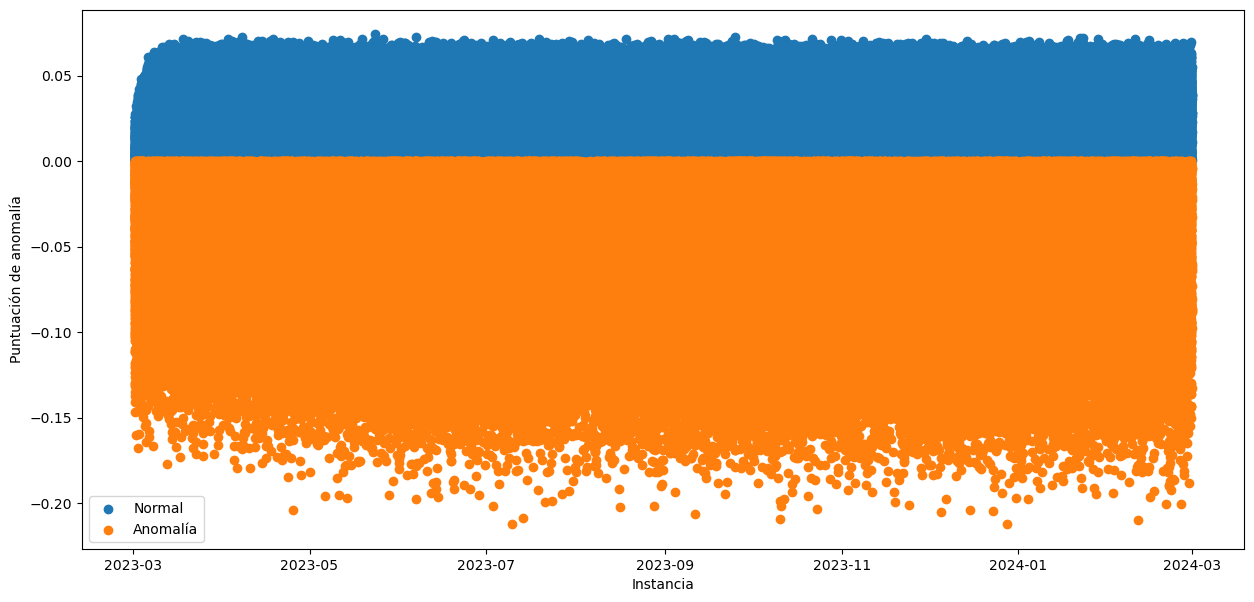

In [75]:
# Visualization of the results
plt.figure(figsize=(15, 7))

# Plot normal instances
normal = df2_agrupado0[df2_agrupado0['anomaly'] == 1]
plt.scatter(normal['timestamp'], normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = df2_agrupado0[df2_agrupado0['anomaly'] == -1]
plt.scatter(anomalies['timestamp'], anomalies['anomaly_score'], label='Anomalía')

plt.xlabel("Instancia")
plt.ylabel("Puntuación de anomalía")
plt.legend()
plt.show()

### KernelSHAP

In [88]:
df_limpio = df2_agrupado0.select_dtypes(include=['number']).astype('float64')

# explainer = shap.Explainer(iso_forest, df_limpio) 

# Seleccionar al azar n instancias normales, y todas las n de anomalías
normal_sample = np.random.choice(normal.index,size=850,replace=False)
sample = np.append(anomalies.index,normal_sample)

# Tomar una sub-muestra de 1000 normales y 1000 anomalías para el gráfico
# Suponiendo que 'sample' son tus índices
sub_sample = np.random.choice(sample, 10000, replace=False)
# shap_values_sub = explainer(features.iloc[sub_sample])
print(f'samples principales: {len(sample)}')
print(f'sub_samples : {len(sub_sample)}')

samples principales: 263824
sub_samples : 10000


In [89]:
# Uso de la puntuación de anomalía y KernelSHAP

# explainer = shap.Explainer(iso_forest.decision_function, features)
# shap_values = explainer(features.iloc[sample])



# # Configura el explainer
# explainer = shap.Explainer(iso_forest.decision_function, features)

# # Define una función para procesar cada muestra
# def compute_shap(row):
#     return explainer(row)

# # Ejecuta en paralelo sobre tu selección de muestras (sample)
# # n_jobs=-1 usará todos tus núcleos
# shap_values_list = Parallel(n_jobs=-1)(
#     delayed(compute_shap)(features.iloc[[i]]) for i in sample
# )


# TreeExplainer es nativo para modelos de árboles y mucho más eficiente
explainer = shap.TreeExplainer(iso_forest)

# Calcula los valores para todo el subset de una vez
# shap_values = explainer(features.iloc[sample])
shap_values = explainer(features.iloc[sub_sample])

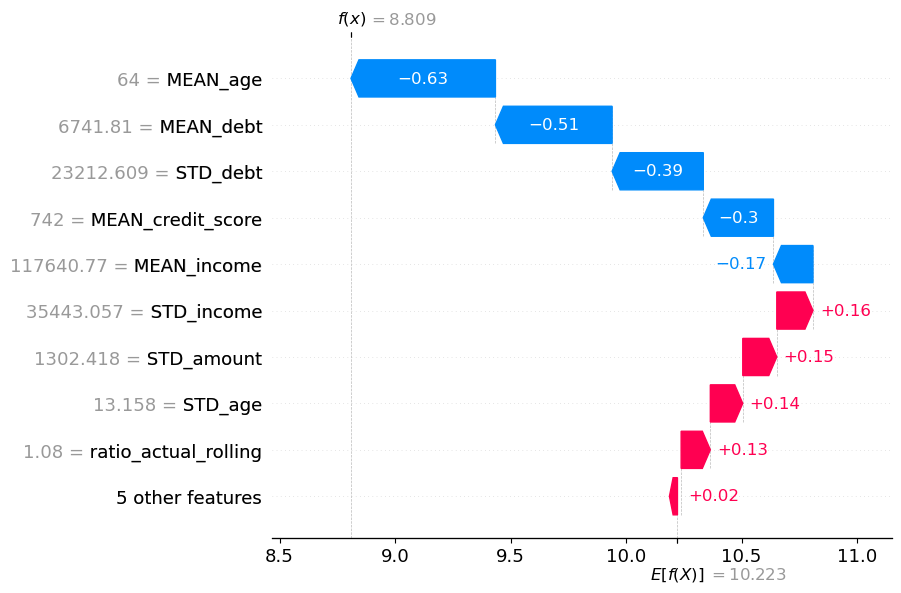

In [90]:
# Gráfico de cascada de una anomalía

shap.plots.waterfall(shap_values[0])
# Punto normal → necesita muchas particiones (deep path) → score cercano a 0
# Punto anómalo → se aísla con pocas particiones (shallow path) → score cercano a 1

Calculando importancia nativa del Isolation Forest...

IMPORTANCIA DE CARACTERISTICAS (metodo nativo)
Basado en frecuencia de uso en los 500 arboles
              feature  importancia
             STD_debt     0.075200
          MEAN_amount     0.074224
          MEAN_income     0.073557
         STD_location     0.073351
 ratio_actual_rolling     0.072735
             MEAN_age     0.071707
        MEAN_location     0.071605
              STD_age     0.071348
     STD_credit_score     0.070629
    MEAN_credit_score     0.070423
           STD_income     0.069910
           STD_amount     0.069396
ratio_actual_location     0.068780
            MEAN_debt     0.067136


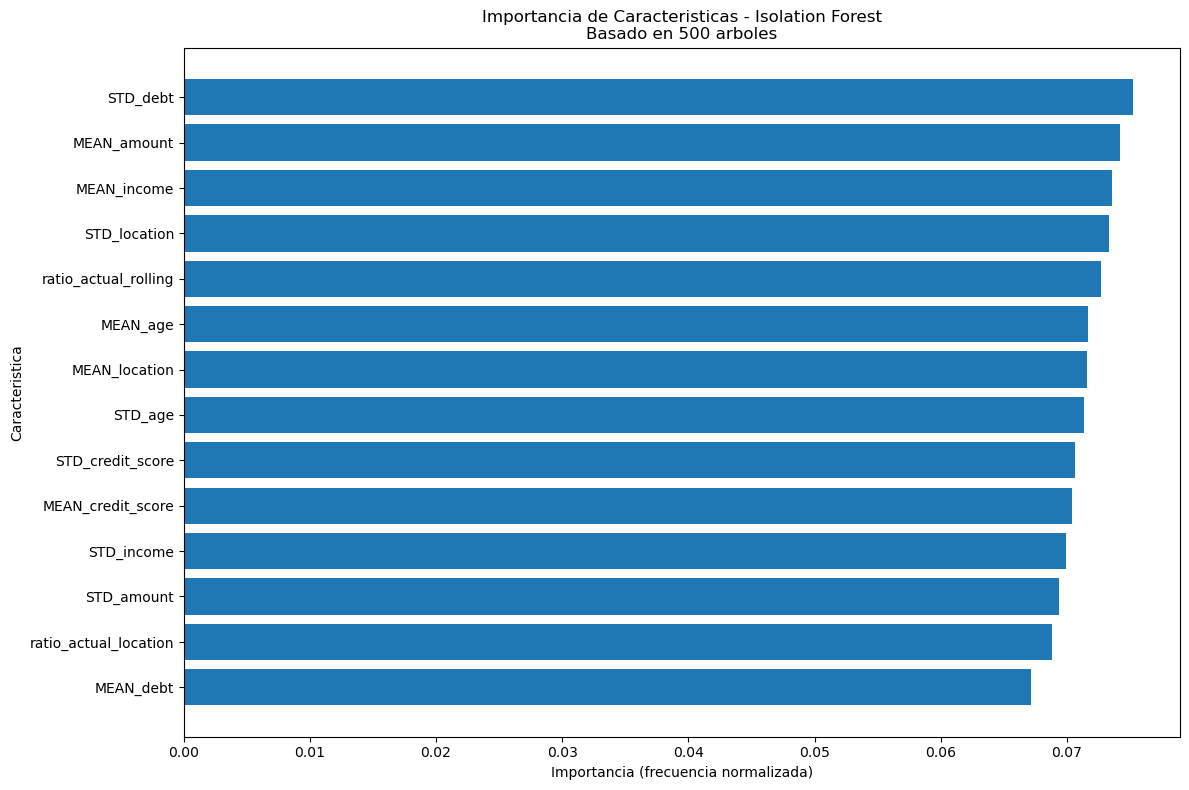


TOP 10 CARACTERISTICAS MAS IMPORTANTES
  1. STD_debt: 0.075200 (7.52%)
  2. MEAN_amount: 0.074224 (7.42%)
  3. MEAN_income: 0.073557 (7.36%)
  4. STD_location: 0.073351 (7.34%)
  5. ratio_actual_rolling: 0.072735 (7.27%)
  6. MEAN_age: 0.071707 (7.17%)
  7. MEAN_location: 0.071605 (7.16%)
  8. STD_age: 0.071348 (7.13%)
  9. STD_credit_score: 0.070629 (7.06%)
  10. MEAN_credit_score: 0.070423 (7.04%)


In [114]:
# METODO NATIVO: EN ARBOLES

def get_feature_importance_native(model, feature_names):
    """
    Calcula importancia basada en cuantas veces cada feature
    es usada para dividir nodos en los arboles.
    """
    n_features = len(feature_names)
    importance = np.zeros(n_features)
    
    # Recorrer todos los arboles
    for tree in model.estimators_:
        tree_obj = tree.tree_
        # Features usadas en cada nodo (-2 indica hoja)
        features_in_tree = tree_obj.feature
        features_in_tree = features_in_tree[features_in_tree >= 0]
        
        # Contar ocurrencias
        for f_idx in features_in_tree:
            if f_idx < n_features:
                importance[f_idx] += 1
    
    # Normalizar a suma = 1
    importance = importance / importance.sum()
    
    return importance

# Calcular importancias
print("Calculando importancia nativa del Isolation Forest...")
importancias_nativas = get_feature_importance_native(iso_forest, feature_names)

# Crear dataframe de resultados
df_importancias = pd.DataFrame({
    'feature': feature_names,
    'importancia': importancias_nativas
}).sort_values('importancia', ascending=False)

# Mostrar resultados
print("\n" + "="*60)
print("IMPORTANCIA DE CARACTERISTICAS (metodo nativo)")
print("Basado en frecuencia de uso en los 500 arboles")
print("="*60)
print(df_importancias.to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# Graficar
plt.figure(figsize=(12, 8))
plt.barh(df_importancias['feature'], df_importancias['importancia'])
plt.xlabel('Importancia (frecuencia normalizada)')
plt.ylabel('Caracteristica')
plt.title(f'Importancia de Caracteristicas - Isolation Forest\nBasado en {iso_forest.n_estimators} arboles')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10
print("\n" + "="*60)
print("TOP 10 CARACTERISTICAS MAS IMPORTANTES")
print("="*60)
for i in range(min(10, len(df_importancias))):
    row = df_importancias.iloc[i]
    print(f"  {i+1}. {row['feature']}: {row['importancia']:.6f} ({100*row['importancia']:.2f}%)")

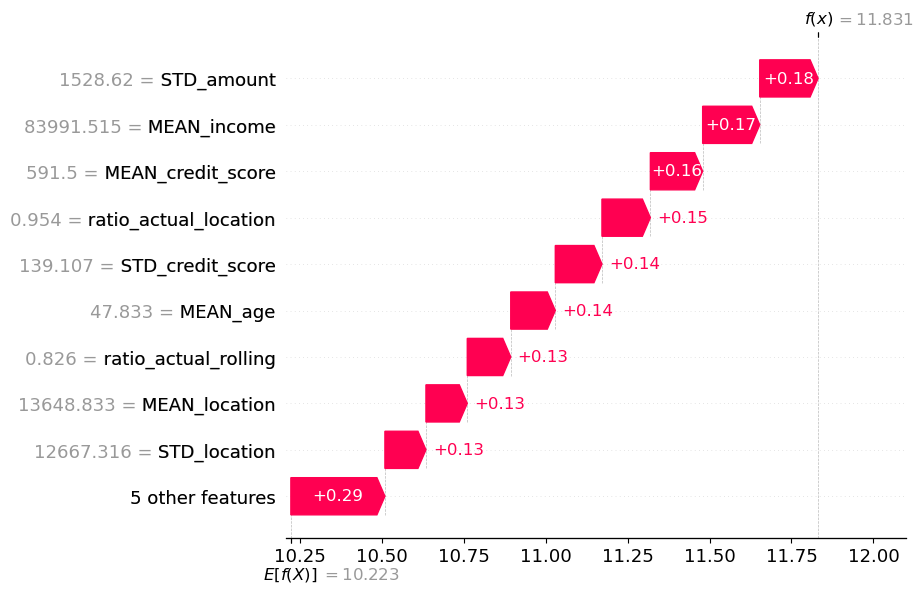

In [91]:
# Gráfico de cascada para una instancia normal
shap.plots.waterfall(shap_values[100])
# valores positivos altos a la izquierda indica mayor anomalía, mientras los valores positivos a la derecha indican menor anomalía

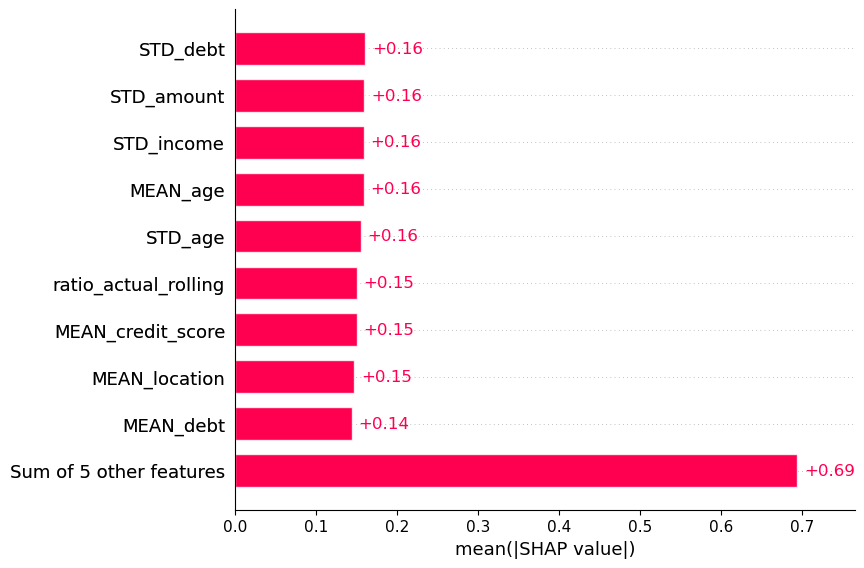

In [92]:
# Gráfico de medias de SHAP Plot
shap.plots.bar(shap_values)

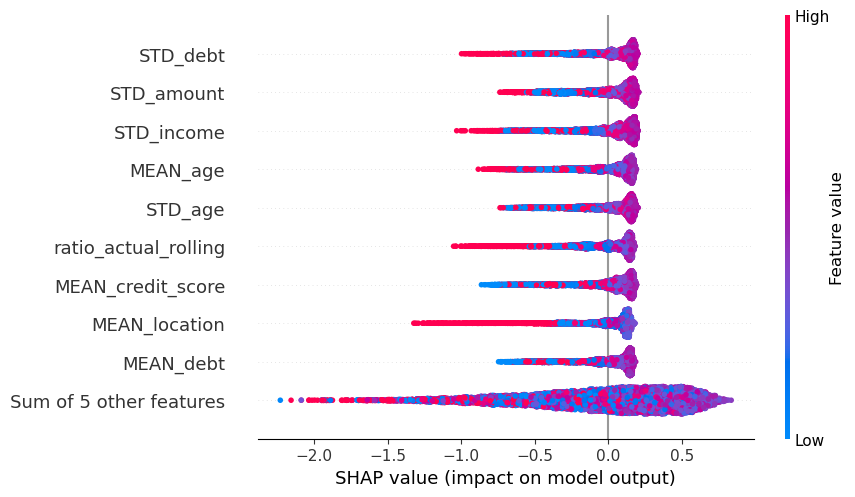

In [93]:
# Gráfico Beeswarm
shap.plots.beeswarm(shap_values)

In [94]:
print('df features')
print(features.info())
print('df2_agrupado0')
print(df2_agrupado0.info())

df features
<class 'pandas.core.frame.DataFrame'>
Index: 525949 entries, 382619 to 121958
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   MEAN_amount            525949 non-null  float64
 1   STD_amount             525949 non-null  float64
 2   MEAN_age               525949 non-null  float64
 3   STD_age                525949 non-null  float64
 4   MEAN_income            525949 non-null  float64
 5   STD_income             525949 non-null  float64
 6   MEAN_debt              525949 non-null  float64
 7   STD_debt               525949 non-null  float64
 8   MEAN_credit_score      525949 non-null  float64
 9   STD_credit_score       525949 non-null  float64
 10  MEAN_location          525949 non-null  float64
 11  STD_location           525949 non-null  float64
 12  ratio_actual_rolling   525949 non-null  float64
 13  ratio_actual_location  525949 non-null  float64
dtypes: float64(14)
memory us

In [95]:
len(y_pred)

525949

In [46]:
# df2_agrupado0['anomaly'] = iso_forest.predict(features)

# valor de fraude real en el df
y_true = (df2_agrupado0['MEAN_is_fraud']).astype(int)
# y_true = df2_agrupado0['MEAN_is_fraud']

# Ajustar formato para evaluación: 1 para anomalía, 0 para normal
y_pred = [1 if x == -1 else 0 for x in df2_agrupado0['anomaly']]

# Generar reporte (asumiendo que tienes 'y_true')
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

              precision    recall  f1-score   support

      Normal       0.97      0.56      0.71    459119
    Anomalía       0.22      0.88      0.36     66830

    accuracy                           0.60    525949
   macro avg       0.60      0.72      0.53    525949
weighted avg       0.88      0.60      0.66    525949



In [126]:
# Obtener scores del modelo
scores = iso_forest.decision_function(features)

# Usar un percentil realista (ej: 5% mas anómalos)
percentile_threshold = 18  # solo 5% marcados como fraude
threshold = np.percentile(scores, percentile_threshold)

# Predecir con nuevo umbral
y_pred_new = (scores < threshold).astype(int)

# Evaluar
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred_new))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89    459119
           1       0.34      0.48      0.40     66830

    accuracy                           0.82    525949
   macro avg       0.63      0.67      0.64    525949
weighted avg       0.85      0.82      0.83    525949



In [47]:
print(y_true.value_counts())

MEAN_is_fraud
0    459119
1     66830
Name: count, dtype: int64


### Por RandomForest

In [43]:
X_shuffled=features
y_shuffled=(df2_agrupado0['MEAN_is_fraud']).astype(int)

# Divide tus datos (X son tus features, y es tu columna de 'anomalia' 0 o 1)
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.3)

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    137748
           1       0.93      0.82      0.87     20037

    accuracy                           0.97    157785
   macro avg       0.95      0.91      0.93    157785
weighted avg       0.97      0.97      0.97    157785



# Isolation Forest como detector de anomalías puro

In [48]:
# Entrenar SIN usar la columna fraude
iso_forest_puro = IsolationForest(
    n_estimators=100,
    contamination='auto',  # nivel exaustivo de anomalias
    random_state=42
)

# Entrenar solo con las features
iso_forest_puro.fit(features)  

#  Obtener scores (mas negativo = mas anomalo)
scores = iso_forest_puro.decision_function(features)

#  Definir umbral (% mas anomalos)
percentile_threshold = 5
threshold = np.percentile(scores, percentile_threshold)
anomalies = scores < threshold

#  Ver cuantas anomalias encontro vs fraudes reales
from sklearn.metrics import confusion_matrix

# Comparar con marca fraude (solo para validacion
cm = confusion_matrix(y_true, anomalies)
print("Matriz de confusion (Isolation Forest puro vs realidad):")
print(f"  Normales correctos: {cm[0,0]}")
print(f"  Falsas anomalias: {cm[0,1]}")
print(f"  Anomalias perdidas: {cm[1,0]}")
print(f"  Anomalias detectadas: {cm[1,1]}")

Matriz de confusion (Isolation Forest puro vs realidad):
  Normales correctos: 444301
  Falsas anomalias: 14818
  Anomalias perdidas: 55350
  Anomalias detectadas: 11480


In [50]:
from pyod.models.iforest import IForest
from pyod.utils.data import generate_data

# Entrenar Isolation Forest
model = IForest()
model.fit(features)

# Obtener importancia DIFFI
feature_importances = model.feature_importances_  # (si está disponible)
# Alternativa: usar la librería EIF para Extended Isolation Forest
# que incluye esta funcionalidad.

Importancia de las variables (DIFFI/Basada en Árboles):
MEAN_debt                0.081510
MEAN_credit_score        0.079230
STD_age                  0.076447
STD_debt                 0.072999
STD_income               0.072586
STD_amount               0.072518
ratio_actual_location    0.070619
STD_location             0.070559
MEAN_location            0.070358
MEAN_amount              0.068801
STD_credit_score         0.068291
MEAN_income              0.066104
MEAN_age                 0.065868
ratio_actual_rolling     0.064110
dtype: float64


<Axes: title={'center': 'Top 10 Variables más importantes'}>

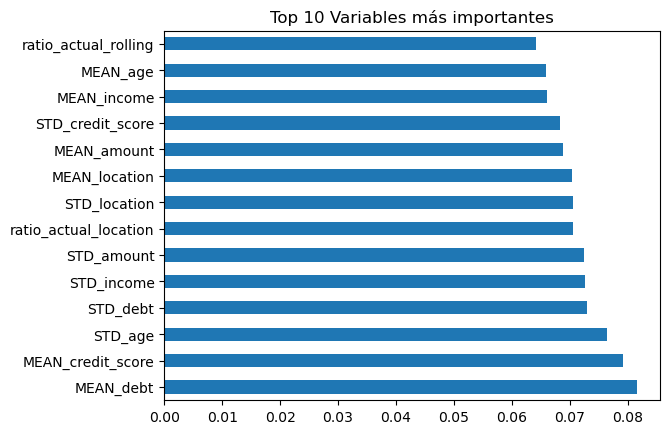

In [54]:
import pandas as pd

# 1. Obtener las importancias
importancias = model.feature_importances_

# 2. Crear una Serie de Pandas vinculando los nombres de las columnas
# Asumiendo que 'features' es el DataFrame que usaste en model.fit()
importancia_df = pd.Series(importancias, index=features.columns)

# 3. Ordenar de mayor a menor y mostrar
importancia_df = importancia_df.sort_values(ascending=False)

print("Importancia de las variables (DIFFI/Basada en Árboles):")
print(importancia_df)

# Opcional: Graficar los resultados
importancia_df.head(9999).plot(kind='barh', title='Top 10 Variables más importantes')


In [6]:
# Generalized Isolation Forest

# Extended Isolation Forest

In [ ]:


model = IsolationForest(
    ntrees=100,                # Número de árboles en el bosque
    sample_size=256,           # Tamaño de la submuestra por árbol
    ndim=2,                    # <-- ESTE ES EL PARÁMETRO CLAVE PARA EIF
    nthreads=4,                # Usa 4 núcleos de CPU para acelerar
    random_seed=42
)

model.fit(features.values)      # Entrenar el modelo
scores = model.predict(features.values)  # Generar scores de anomalía